In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import nltk
from sklearn.model_selection import train_test_split
import seaborn as sns
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer

In [2]:
df = pd.read_csv("spam.csv",encoding="latin-1")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
# 1)data cleaning
# 2)EDA
# 3)Text Preproccesing
# 4)Model Building
# 5)Evaluation 
# 6)Improvement

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df = df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"])

In [8]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.value_counts("v1")

v1
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
#Renaming the columns 
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df['target'] = df['target'].map({"ham":0,"spam":1})

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
#missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
#check for duplicated values
print(df.duplicated().sum())

403


In [15]:
df = df.drop_duplicates(keep="first")

In [16]:
print(df.duplicated().sum())

0


In [17]:
df.shape

(5169, 2)

In [18]:
#EDA
df.value_counts("target")

target
0    4516
1     653
Name: count, dtype: int64

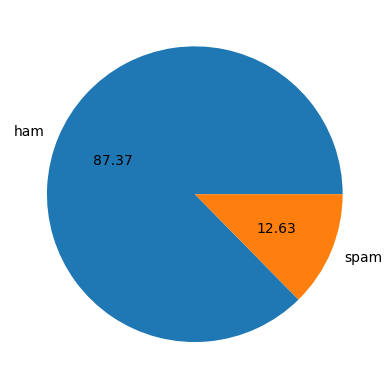

In [19]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [20]:
#data is imbalanced

In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\siddharth
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\siddharth
[nltk_data]     Tiwari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
df['num_characters']=df['text'].apply(len) # no of charecters in each row of text column

In [23]:
#num of words
df["num_of_words"]=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [24]:
df.head()

,target,text,num_characters,num_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
df["num_sentences"]=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,target,text,num_characters,num_of_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[['num_characters','num_of_words','num_sentences']].describe()

,num_characters,num_of_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
#ham
df[df['target']==0][['num_characters','num_of_words','num_sentences']].describe()

,num_characters,num_of_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
#spam
df[df['target']==1][['num_characters','num_of_words','num_sentences']].describe()

,num_characters,num_of_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

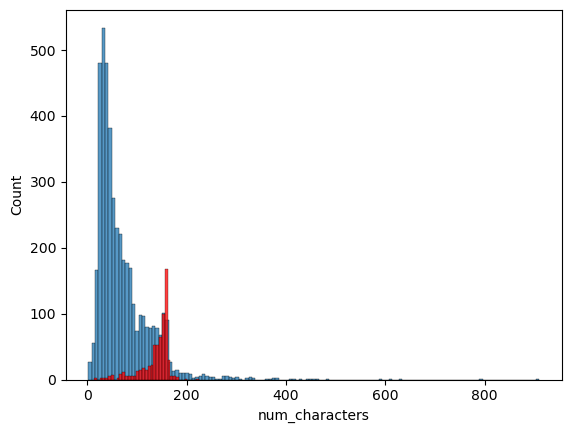

In [30]:
# Histogram for both ham and span
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_of_words', ylabel='Count'>

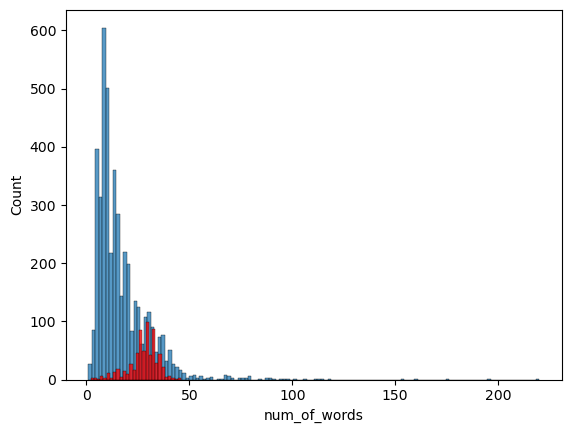

In [31]:
sns.histplot(df[df['target']==0]['num_of_words'])
sns.histplot(df[df['target']==1]['num_of_words'],color='red')

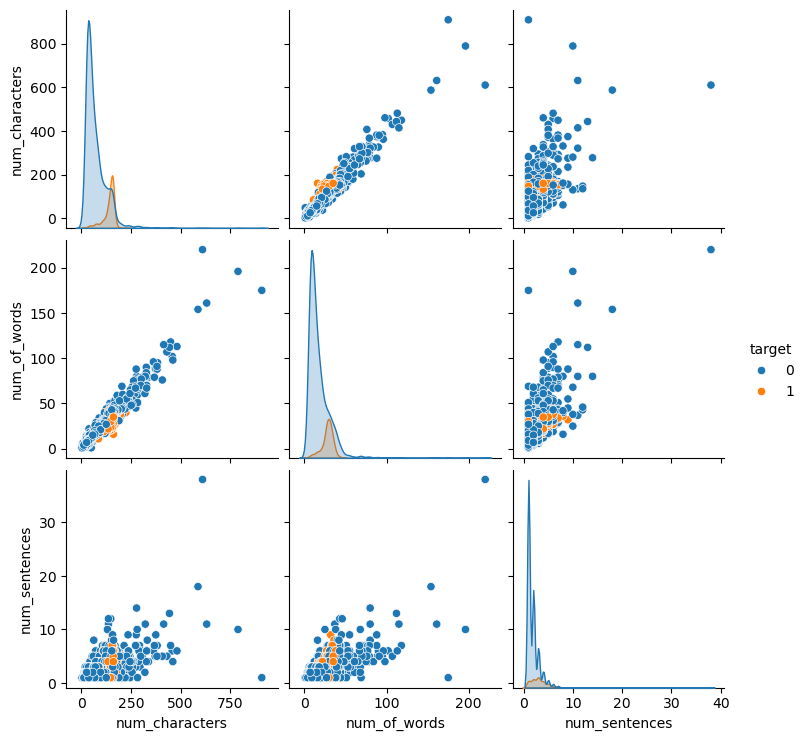

In [32]:
sns.pairplot(df,hue='target')

<Axes: >

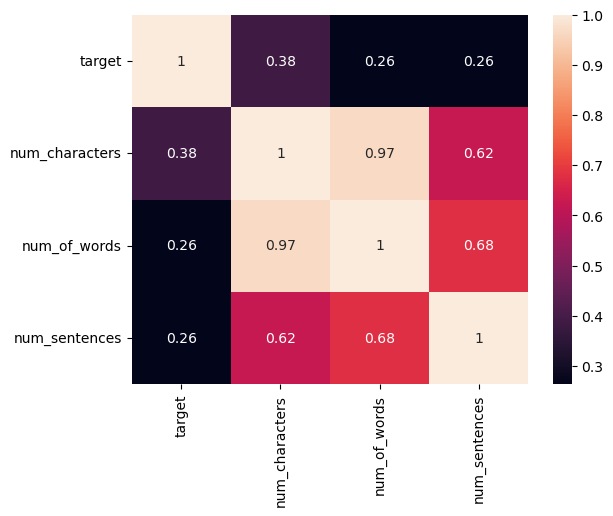

In [33]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

In [34]:
# we have to keep only one column which will be num of characters becoz of multicollinearity  highly correlated data
 

In [35]:
#Data Preprocessing
#-lower case
#tokenization
#removing special characters
#removing stop words and punctuation
#removing stopwords and punctuation
#stemmmming

In [36]:
ps = PorterStemmer()
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [37]:
transform_text('is your age 25% , Siddharth ?')

'age 25 siddharth'

In [38]:
transform_text("Do you like my coding skills ?")

'like code skill'

In [39]:
transform_text('I love playing Badminton and chess. what about you?')

'love play badminton chess'

In [40]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [41]:

df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [42]:
df['transformed_text']=df['text'].apply(transform_text)



In [43]:
df.head()

,target,text,num_characters,num_of_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [44]:
from wordcloud import WordCloud

In [45]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

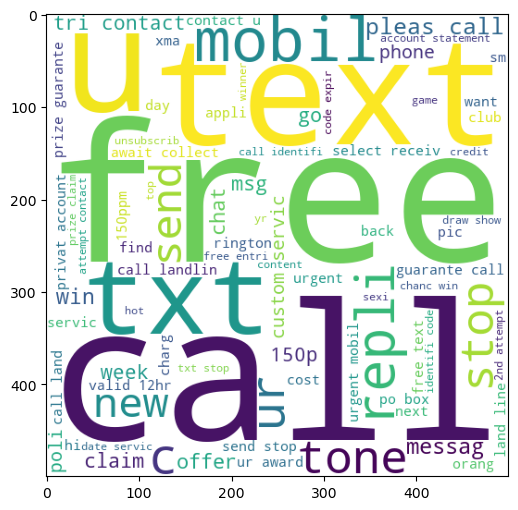

In [46]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

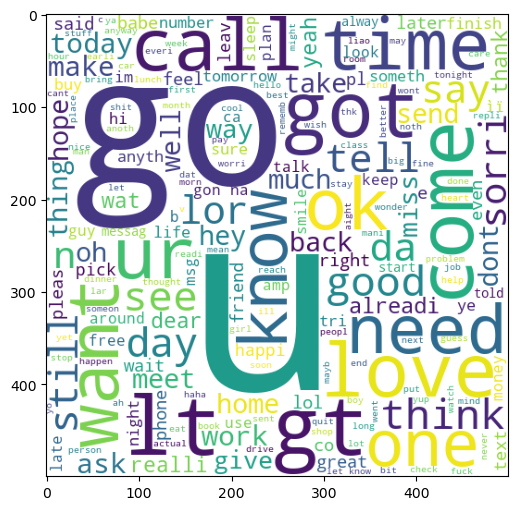

In [47]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [48]:
df.head()

,target,text,num_characters,num_of_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [49]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)
    

In [50]:
len(spam_corpus)

9939

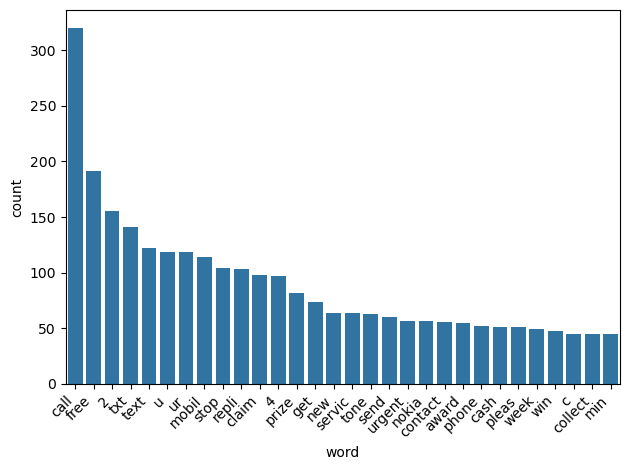

In [51]:
from collections import Counter

# Store it so you don't compute it twice
top30 = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

sns.barplot(data=top30, x='word', y='count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

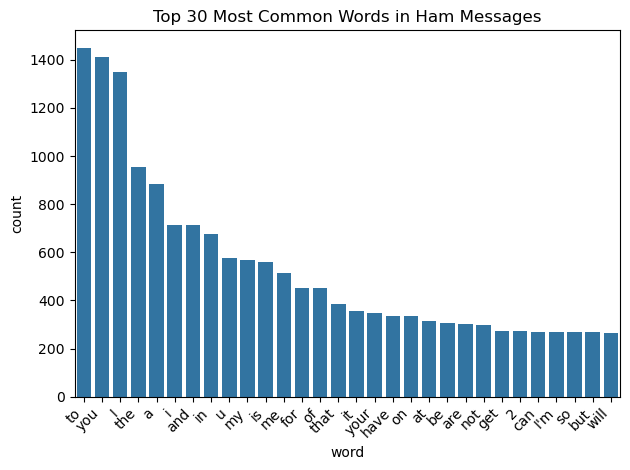

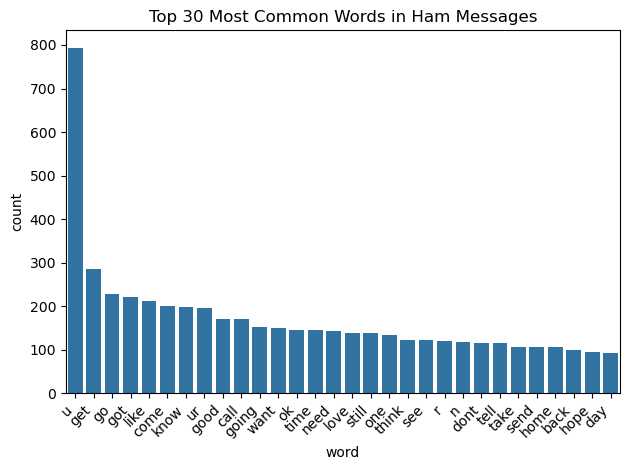

In [52]:
ham_corpus = []
for msg in df[df['target'] == 0]['text']: 
    for word in msg.split():
        ham_corpus.append(word)


top30_ham = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

sns.barplot(data=top30_ham, x='word', y='count')
plt.title('Top 30 Most Common Words in Ham Messages')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

ham_corpus = []
for msg in df[df['target'] == 0]['text']:
    for word in msg.lower().split():
        if word.isalpha() and word not in stop_words:
            ham_corpus.append(word)

top30_ham = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

sns.barplot(data=top30_ham, x='word', y='count')
plt.title('Top 30 Most Common Words in Ham Messages')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




In [53]:
#Model Building
#1) Vectorizing the data with bag of words
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer


In [54]:
Y = df['target'].values

In [55]:
Y

array([0, 0, 1, ..., 0, 0, 0])

In [56]:
X_train_text, X_test_text, Y_train, Y_test = train_test_split(
    df['transformed_text'], df['target'],
    test_size=0.2, random_state=42
)
tfidf = TfidfVectorizer(max_features=3000)
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

In [57]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [58]:
gnb = GaussianNB()
mnb = MultinomialNB(alpha=0.1)
bnb = BernoulliNB()

In [59]:
# gnb.fit(X_train,Y_train)
# y_pred1 = gnb.predict(X_test)
# print(accuracy_score(y_pred1,Y_test))
# print(confusion_matrix(y_pred1,Y_test))
# print(precision_score(y_pred1,Y_test))

In [60]:
mnb.fit(X_train,Y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(Y_test,y_pred2))
print(confusion_matrix(Y_test,y_pred2))
print(precision_score(Y_test,y_pred2))


0.9758220502901354
[[884   5]
 [ 20 125]]
0.9615384615384616


In [61]:
bnb.fit(X_train,Y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(Y_test,y_pred3))
print(confusion_matrix(Y_test,y_pred3))
print(precision_score(Y_test,y_pred3))


0.9748549323017408
[[886   3]
 [ 23 122]]
0.976


In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
rc = RandomForestClassifier(random_state=42)


In [64]:
rc.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [65]:
y_pred = rc.predict(X_test)
print(accuracy_score(Y_test,y_pred))
print(confusion_matrix(Y_test,y_pred))
print(precision_score(Y_test,y_pred))


0.971953578336557
[[888   1]
 [ 28 117]]
0.9915254237288136


In [66]:

# from sklearn.feature_extraction.text import TfidfVectorizer

# X_train_text, X_test_text, Y_train, Y_test = train_test_split(
#     df['transformed_text'], df['target'],
#     test_size=0.2, random_state=42
# )

# tfidf = TfidfVectorizer(max_features=3000)
# X_train = tfidf.fit_transform(X_train_text)
# X_test = tfidf.transform(X_test_text)

# # Best model
# mnb = MultinomialNB(alpha=0.1)
# mnb.fit(X_train, Y_train)
# y_pred = mnb.predict(X_test)

# print("Accuracy :", accuracy_score(Y_test, y_pred))
# print("Precision:", precision_score(Y_test, y_pred))
# print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred))

In [67]:
from sklearn.svm import SVC

In [68]:
sv = SVC(kernel='linear',C=1,random_state=42)
sv.fit(X_train,Y_train)

SVC(C=1, kernel='linear', random_state=42)

In [69]:
y_pred5 = sv.predict(X_test)
print(accuracy_score(Y_test,y_pred5))
print(confusion_matrix(Y_test,y_pred5))
print(precision_score(Y_test,y_pred5))


0.9835589941972921
[[887   2]
 [ 15 130]]
0.9848484848484849


In [70]:
from sklearn.model_selection import RandomizedSearchCV

In [71]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,           # try 20 random combinations
    cv=5,                # 5-fold cross validation
    scoring='precision', # optimize for precision
    n_jobs=-1,           # use all CPU cores
    verbose=2,
    random_state=42
)

In [72]:
random_search.fit(X_train,Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='precision', verbose=2)

In [73]:
random_search.best_params_
random_search.best_score_

np.float64(1.0)

In [74]:
y_pred6 = random_search.predict(X_test)
print(accuracy_score(Y_test,y_pred6))
print(confusion_matrix(Y_test,y_pred6))
print(precision_score(Y_test,y_pred6))


0.9584139264990329
[[888   1]
 [ 42 103]]
0.9903846153846154


In [75]:
# Check training score vs test score
y_train_pred = rc.predict(X_train)
y_test_pred = rc.predict(X_test)

print("--- Training ---")
print("Accuracy :", accuracy_score(Y_train, y_train_pred))
print("Precision:", precision_score(Y_train, y_train_pred))

print("\n--- Test ---")
print("Accuracy :", accuracy_score(Y_test, y_test_pred))
print("Precision:", precision_score(Y_test, y_test_pred))

--- Training ---
Accuracy : 0.9992744860943168
Precision: 1.0

--- Test ---
Accuracy : 0.971953578336557
Precision: 0.9915254237288136


In [76]:
y_train_pred_sv = sv.predict(X_train)
y_test_pred_sv  = sv.predict(X_test)

print("--- SVC Training ---")
print("Accuracy :", accuracy_score(Y_train, y_train_pred_sv))
print("Precision:", precision_score(Y_train, y_train_pred_sv))

print("\n--- SVC Test ---")
print("Accuracy :", accuracy_score(Y_test, y_test_pred_sv))
print("Precision:", precision_score(Y_test, y_test_pred_sv))

--- SVC Training ---
Accuracy : 0.9920193470374848
Precision: 0.9917184265010351

--- SVC Test ---
Accuracy : 0.9835589941972921
Precision: 0.9848484848484849


In [77]:
# so we choose support vector machine model for our project
import joblib
joblib.dump(sv, 'spam_model.pkl')
joblib.dump(tfidf, 'vectorizer.pkl')

['vectorizer.pkl']

In [78]:
model = joblib.load('spam_model.pkl')
vectorizer = joblib.load('vectorizer.pkl')

def predict_spam(text):
    transformed = transform_text(text)
    vectorized = vectorizer.transform([transformed])
    result = model.predict(vectorized)[0]
    return "SPAM" if result == 1 else "HAM"

# Quick test

print(predict_spam("Hey are we still meeting tomorrow?"))
print(predict_spam("Congratulations! You win a free iPhone click now!"))  
print(predict_spam("FREE entry win £1000 cash prize call now!"))          
print(predict_spam("Hey are we still meeting tomorrow?"))                  
print(predict_spam("Bro what time are you coming tonight?")) 

HAM
SPAM
SPAM
HAM
HAM


In [79]:
# Evaluation
tests = [
    "congratul free iphon click",
    "free prize winner claim call",
    "win cash prize free click now urgent",
    "you have won free entry claim prize money",
    "free tone ringtone mobil latest",   # actual spam words from corpus
    "urgent cash prize winner claim free",
]

for t in tests:
    vectorized = tfidf.transform([t])
    pred = sv.predict(vectorized)[0]
    print(f"{'SPAM' if pred==1 else 'HAM':5s} ← {t}")

HAM   ← congratul free iphon click
SPAM  ← free prize winner claim call
SPAM  ← win cash prize free click now urgent
SPAM  ← you have won free entry claim prize money
SPAM  ← free tone ringtone mobil latest
SPAM  ← urgent cash prize winner claim free
